In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

In [2]:
# Load Processed Data
data = np.load('processed_wdbc.npz')
X_full = data['X']
y_full = data['y']

# Real feature names
feature_names = [
    'Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area', 'Mean Smoothness',
    'Mean Compactness', 'Mean Concavity', 'Mean Concave Points', 'Mean Symmetry', 'Mean Fractal Dimension',
    'Radius SE', 'Texture SE', 'Perimeter SE', 'Area SE', 'Smoothness SE',
    'Compactness SE', 'Concavity SE', 'Concave Points SE', 'Symmetry SE', 'Fractal Dimension SE',
    'Worst Radius', 'Worst Texture', 'Worst Perimeter', 'Worst Area', 'Worst Smoothness',
    'Worst Compactness', 'Worst Concavity', 'Worst Concave Points', 'Worst Symmetry', 'Worst Fractal Dimension'
]

X_df = pd.DataFrame(X_full, columns=feature_names)
print("✅ Data Loaded Successfully")
print("Shape of X:", X_df.shape)
print("Shape of y:", y_full.shape)

✅ Data Loaded Successfully
Shape of X: (569, 30)
Shape of y: (569,)


In [3]:
# Feature Distribution
X_df.describe()

,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,Mean Fractal Dimension,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,...,-8.241796e-16,1.248757e-17,-3.746271e-16,0.000000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-0.642136,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-0.341181,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,0.357589,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


In [4]:
# 4. Feature Engineering - Ratios
X_df['Area_Radius_Ratio'] = X_df['Mean Area'] / (X_df['Mean Radius'] ** 2)
X_df['Perimeter_Radius_Ratio'] = X_df['Mean Perimeter'] / X_df['Mean Radius']

In [5]:
# 5. Feature Engineering - Interaction Terms
X_df['Smoothness_Concavity'] = X_df['Mean Smoothness'] * X_df['Mean Concavity']
X_df['Symmetry_Fractal'] = X_df['Mean Symmetry'] * X_df['Mean Fractal Dimension']

In [6]:
# 6. Feature Engineering - PCA Features
# Apply PCA on Mean Features only
mean_features = [col for col in X_df.columns if col.startswith('Mean')]
pca = PCA(n_components=3, random_state=42)
pca_components = pca.fit_transform(X_df[mean_features])

X_df['PCA1'] = pca_components[:, 0]
X_df['PCA2'] = pca_components[:, 1]
X_df['PCA3'] = pca_components[:, 2]

print("\n✅ PCA Features Added: PCA1, PCA2, PCA3")


✅ PCA Features Added: PCA1, PCA2, PCA3


In [7]:
# 7. Feature Engineering - Statistical Aggregates
# Mean and StdDev of Mean Features
X_df['Mean_Feature_Mean'] = X_df[mean_features].mean(axis=1)
X_df['Mean_Feature_StdDev'] = X_df[mean_features].std(axis=1)

print("\n✅ Aggregate Statistical Features Added")


✅ Aggregate Statistical Features Added


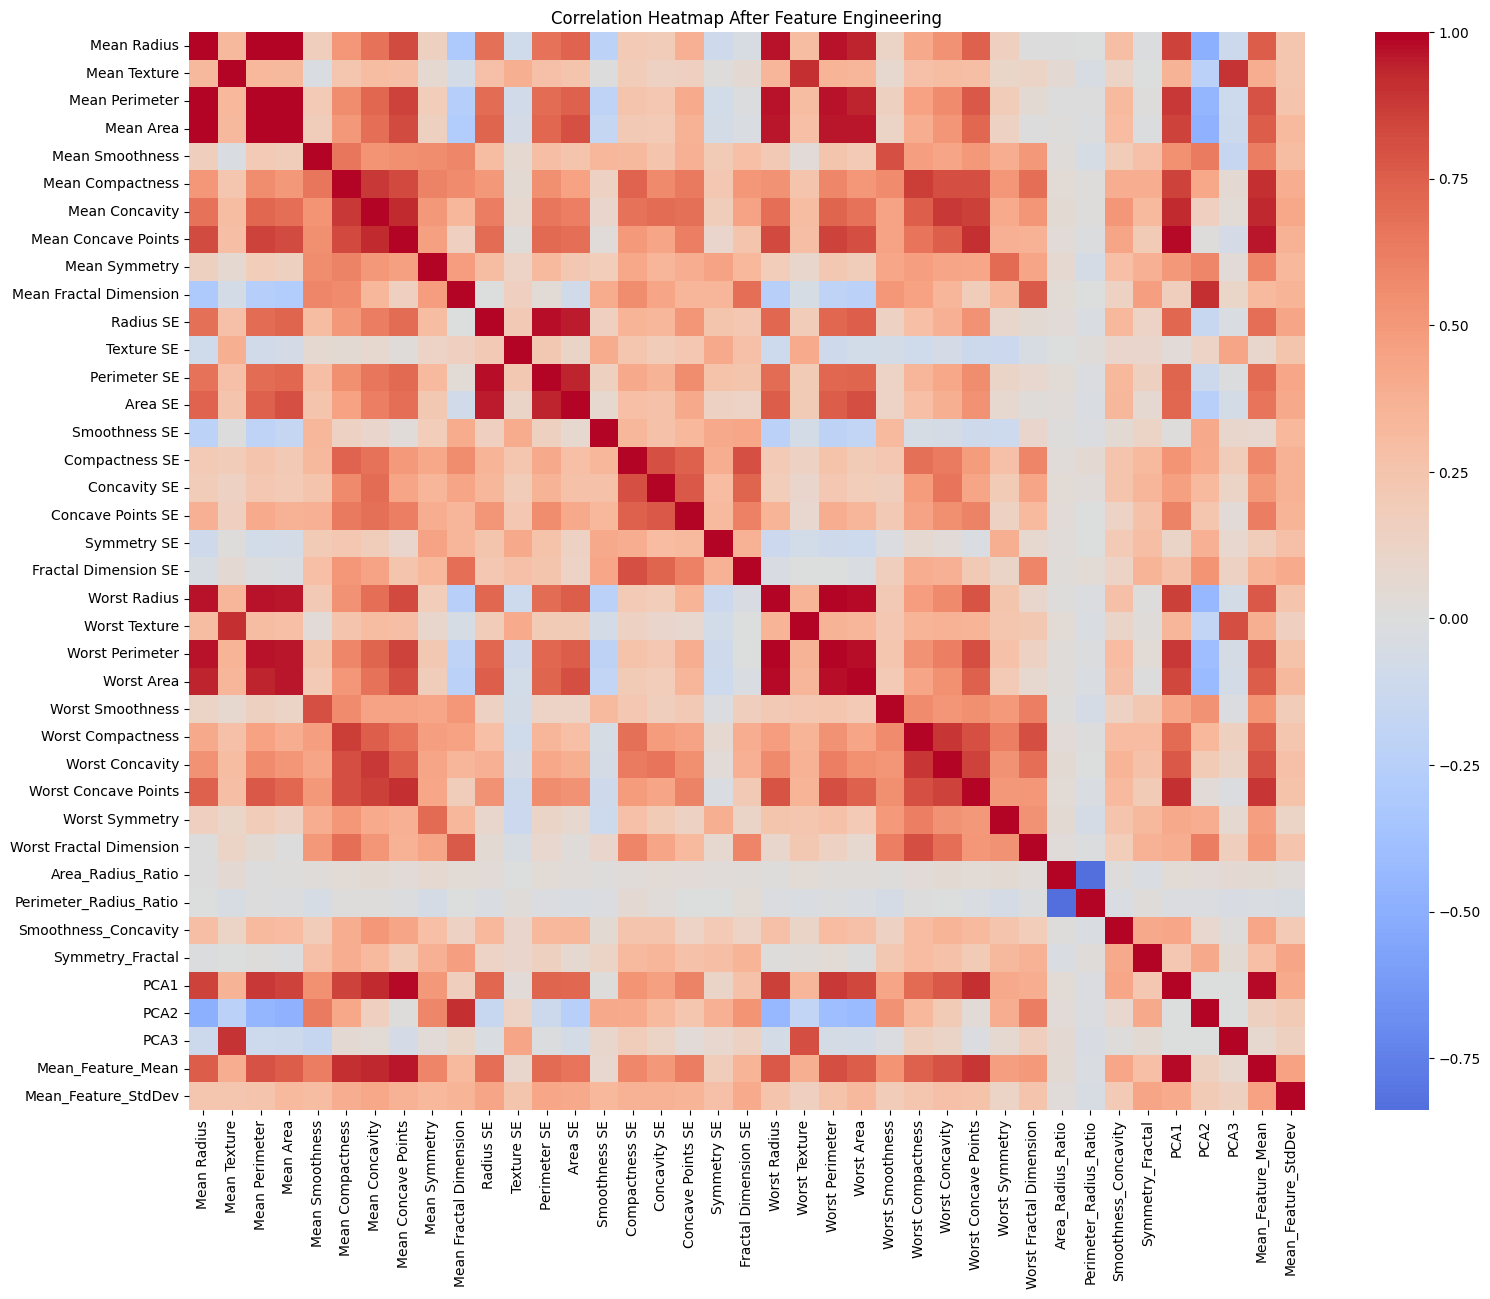

In [8]:
plt.figure(figsize=(18, 14))
corr = X_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Heatmap After Feature Engineering")
plt.show()

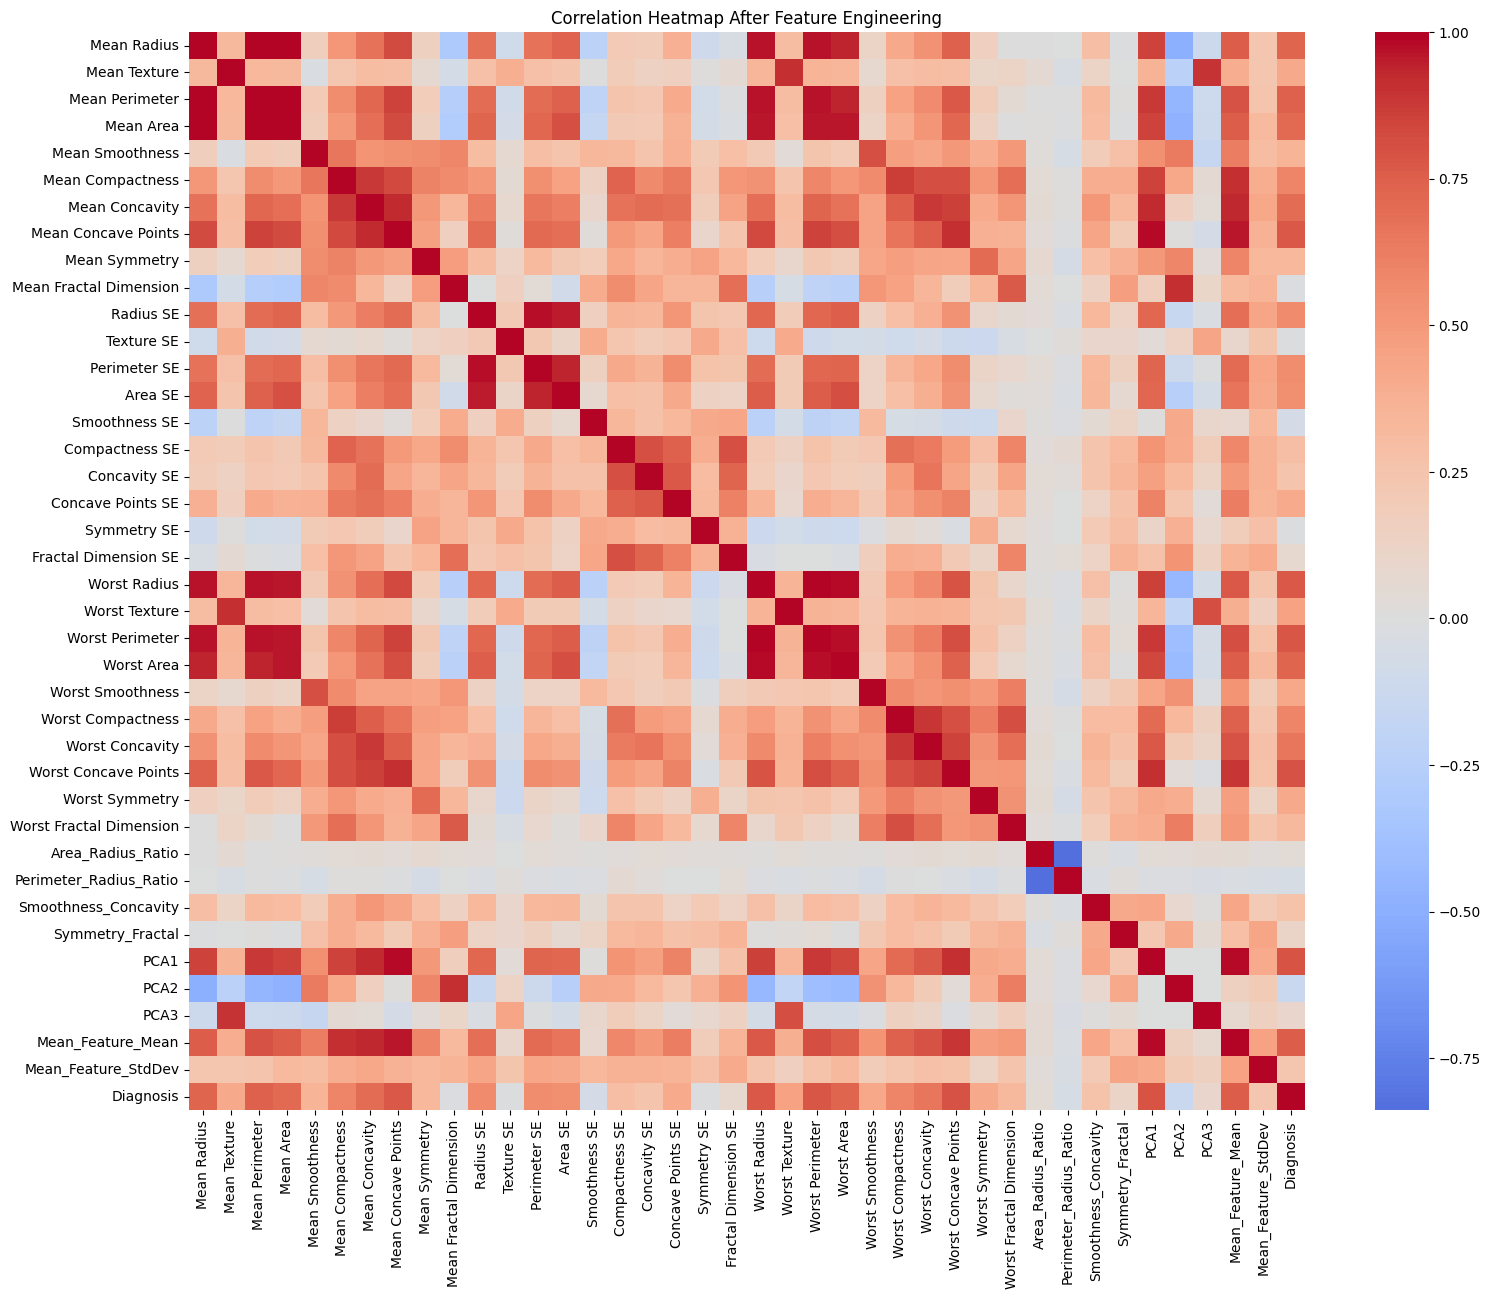


🔍 Top 10 Correlated Features (After Feature Engineering):
Worst Concave Points    0.793566
PCA1                    0.785434
Worst Perimeter         0.782914
Mean Concave Points     0.776614
Worst Radius            0.776454
Mean_Feature_Mean       0.760188
Mean Perimeter          0.742636
Worst Area              0.733825
Mean Radius             0.730029
Mean Area               0.708984
Name: Diagnosis, dtype: float64


In [11]:
X_df['Diagnosis'] = y_full  # temporarily add 

plt.figure(figsize=(18, 14))
corr = X_df.corr()  # calculate correlation after Diagnosis is added
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Heatmap After Feature Engineering")
plt.show()

# 10. New Feature Importance (Simple Correlation Check with Diagnosis)
top_corr_features = corr['Diagnosis'].abs().sort_values(ascending=False).drop('Diagnosis')[:10]
print("\n🔍 Top 10 Correlated Features (After Feature Engineering):")
print(top_corr_features)
 
X_df.drop(columns=['Diagnosis'], inplace=True) # remove Diagnosis 

In [12]:
# Save Engineered Dataset
X_engineered = X_df.values
np.savez('processed_wdbc_engineered.npz', X=X_engineered, y=y_full)

print("\n✅ Engineered dataset saved as 'processed_wdbc_engineered.npz'")
print("Final Shape of X:", X_engineered.shape)


✅ Engineered dataset saved as 'processed_wdbc_engineered.npz'
Final Shape of X: (569, 39)


C:\Users\Aayush Pradhan\AppData\Local\Temp\ipykernel_3080\1175478885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


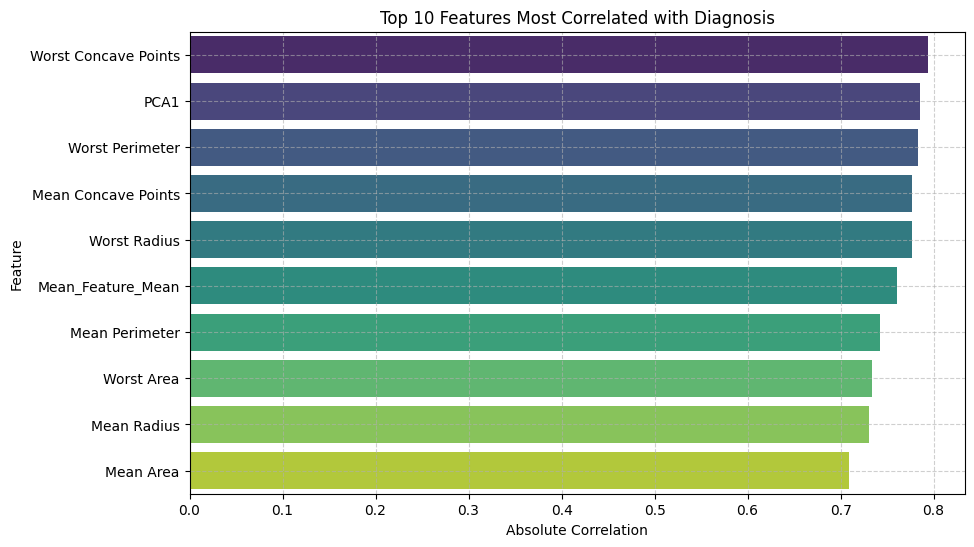

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_corr_features.values,
    y=top_corr_features.index,
    palette='viridis'
)
plt.title('Top 10 Features Most Correlated with Diagnosis')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()